In [1]:
import pandas as pd
from scipy.io import loadmat

from Master1_MH_RA.fundrating import MVSK, LMoments, TLMoments, TF_RA, TF_RL, MVSKRating

import ffn
import bt

# Load data

In [2]:
temp = loadmat('/home/kepiej/Dropbox/TRen/Matlab Codes & Ignace Python Codes/Master 1-MH Rating with Robust Moment-Matlab Code/187HF_rawreturn_FromOct2006toOct2020.mat')
index = pd.date_range(start=pd.Timestamp('2006-10-01 00:00:00'), end=pd.Timestamp('2020-10-01 00:00:00'), freq='MS', name='Date')
rEff = pd.DataFrame(data=temp['rawreturn'], index=index)
rEff.head()

,0,1,2,3,4,5,6,7,8,9,...,177,178,179,180,181,182,183,184,185,186
Date,,,,,,,,,,,,,,,,,,,,,
2006-10-01,-0.007098,0.065800,0.028801,0.137400,0.094299,0.018584,0.074803,0.012296,0.004908,0.015272,...,0.002402,0.008000,0.007927,0.0514,0.035499,0.014809,0.035009,0.007499,0.010100,0.016496
2006-11-01,0.004898,-0.025301,0.058501,0.197500,0.125300,0.015830,0.059499,0.026200,-0.046398,0.028765,...,0.020831,0.001999,0.001180,0.0266,0.033000,0.032408,0.030409,0.026400,0.026000,0.023479
2006-12-01,0.012099,0.003801,-0.019502,-0.142700,-0.091801,0.031432,0.025400,0.016101,0.006402,0.024809,...,-0.000751,0.009000,0.009427,0.0260,0.010500,0.021371,0.010503,0.042601,0.039600,0.069818
2007-01-01,0.034800,0.006600,0.026001,-0.000801,0.006800,0.004866,-0.004903,0.035600,0.001272,0.010549,...,-0.007517,0.009001,0.010895,0.0246,0.015001,0.038597,-0.011224,0.014300,0.013400,0.001552
2007-02-01,0.024603,-0.001201,0.020501,0.121500,0.070002,0.001529,-0.032297,-0.061199,0.022872,0.013907,...,0.030895,0.011000,0.010393,-0.0283,0.010700,-0.059314,0.034732,0.014800,0.012899,0.003151


In [3]:
# BT expects a price matrix: convert returns matrix to prices matrix
prices = pd.concat([pd.DataFrame(data=100, index=[rEff.index[0] - pd.DateOffset(months=1)], columns=pd.RangeIndex(0, rEff.shape[1])), ffn.core.to_price_index(rEff)], axis=0)
#ffn.core.to_returns(prices).dropna()
prices.head()

,0,1,2,3,4,5,6,7,8,9,...,177,178,179,180,181,182,183,184,185,186
2006-09-01,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2006-10-01,99.290170,106.579990,102.880109,113.739979,109.429947,101.858431,107.480284,101.229612,100.490798,101.527214,...,100.240192,100.800008,100.792707,105.140000,103.549902,101.480880,103.500852,100.749942,101.010010,101.649633
2006-11-01,99.776501,103.883402,108.898651,136.203569,123.141569,103.470894,113.875283,103.881871,95.828221,104.447677,...,102.328263,101.001515,100.911613,107.936703,106.967027,104.769641,106.648211,103.409729,103.636293,104.036275
2006-12-01,100.983690,104.278277,106.774963,116.767387,111.837093,106.723148,116.767754,105.554425,96.441718,107.038965,...,102.251401,101.910568,101.862862,110.743072,108.090198,107.008665,107.768313,107.815038,107.740308,111.299842
2007-01-01,104.497918,104.966501,109.551171,116.673904,112.597546,107.242416,116.195272,109.312173,96.564417,108.168108,...,101.482786,102.827840,102.972652,113.467351,109.711645,111.138882,106.558773,109.356808,109.184028,111.472578


# Load Data Base Europe Edgar

In [ ]:
data = pd.read_excel("./Master1_MH_RA/Data Base Europe Edgar.xlsx")
data = data.dropna(axis=1)
data.head(10)

In [4]:
#data_prices = data.iloc[6:]
#data_prices = data_prices.infer_objects().set_index('Ticker\n')
# Downsample price data to monthly level by taking daily prices at end of each month
#data_prices = data_prices.resample('ME').nearest()
#data_prices.to_parquet("Data_Edgar_Europe_prices.parquet")
data_prices = pd.read_parquet("Data_Edgar_Europe_prices.parquet")
#data_prices = data_prices.resample('B').last()
data_prices

,CPRFDOO FP Equity,AMUFDAC FP Equity,AMU6COL FP Equity,AMU3COL FP Equity,PIOBERY FP Equity,AMREMOC FP Equity,AMURSOC FP Equity,GALAXIA FP Equity,CRESAOD FP Equity,SGAMGXS FP Equity,...,TDNUCBI LN Equity,TDNJPGI LN Equity,TDNESCI LN Equity,TDNEUGI LN Equity,DEKRENT GR Equity,TGESRNA LN Equity,DEKEURS GR Equity,TDNUKMI LN Equity,DEKNAWA GR Equity,TDNASGI LN Equity
Ticker,,,,,,,,,,,,,,,,,,,,,
2014-09-25,1020.94,1153.45,11202.15,10540.51,15261.25,103.79,109.55,1071.000000,139.580002,1065.28,...,57.55,39.13,460.92,161.01,37.14,153.72,51.30,73.15,110.51,180.71
2014-09-26,1019.58,1160.74,11252.07,10538.38,14893.09,103.73,109.58,1071.000000,139.740005,1065.29,...,57.57,39.01,456.01,159.37,37.08,152.37,50.79,72.53,110.84,177.58
2014-09-29,1018.89,1155.56,11154.90,10536.65,14893.09,103.71,109.41,1071.050049,139.550003,1065.27,...,57.46,39.22,456.08,158.92,36.99,152.77,50.82,72.41,110.39,179.00
2014-09-30,1018.13,1159.93,11272.65,10541.76,15003.21,103.63,109.47,1071.069946,139.610001,1065.28,...,57.40,38.93,455.40,159.22,36.96,152.70,50.89,72.46,110.56,180.15
2014-10-01,1018.97,1154.75,11174.39,10551.00,14833.57,103.69,109.59,1071.040039,139.839996,1065.38,...,57.58,38.49,456.66,159.55,37.03,152.30,51.05,72.18,110.45,179.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-19,1149.39,1154.09,24253.86,11172.26,26110.99,106.83,127.26,1144.470000,143.750000,1144.45,...,55.54,94.66,1074.59,373.71,35.34,328.73,104.71,73.61,114.43,597.30
2024-09-20,1151.58,1148.37,24033.34,11167.21,25654.90,106.80,127.50,1144.880000,143.610000,1143.72,...,55.42,94.69,1066.72,373.20,35.39,326.95,104.17,73.03,114.90,601.26
2024-09-23,1152.60,1159.29,24033.83,11181.43,25582.49,106.80,127.77,1145.270000,144.050000,1145.38,...,55.39,94.95,1054.69,368.02,35.43,325.19,103.50,72.37,115.05,598.47


In [5]:
#data_costs = data.iloc[2:5]
#data_costs.to_parquet("Data_Edgar_Europe_costs.parquet")
data_costs = pd.read_parquet("Data_Edgar_Europe_costs.parquet")
data_costs = data_costs.set_index('Ticker\n').T
data_costs

Ticker,Entry Cost,Exit Cost,Yearly Cost
CPRFDOO FP Equity,20.00,0.0,0.26
AMUFDAC FP Equity,20.00,0.0,0.12
AMU6COL FP Equity,20.00,0.0,0.31
AMU3COL FP Equity,20.00,0.0,0.19
PIOBERY FP Equity,15.00,4.0,0.56
...,...,...,...
TGESRNA LN Equity,3.75,0.0,1.65
DEKEURS GR Equity,3.75,0.0,1.44
TDNUKMI LN Equity,3.75,0.0,1.54
DEKNAWA GR Equity,3.75,0.0,1.98


# Test bt

In [6]:
def getBackTestList(price_df: pd.DataFrame, max_window_years: int = 5, getXYgXgY = TF_RA, nr_moments: int = 4):

    #index_startdate = rEff.index[0] + pd.DateOffset(years=5) - pd.DateOffset(months=1)
    index_startdate = price_df.index[1] + pd.DateOffset(years=max_window_years) - pd.DateOffset(months=1)

    # Vary the rebalancing time by generating a new strategy for every rebalance. This eliminates the effect of timing.
    testlist = []
    #nrebalances = price_df.shape[0] - 1 - (2*max_window_years*12) - 1
    nrebalances = (price_df.index.max().to_period('M') - price_df.index.min().to_period('M')).n - (2*max_window_years*12) - 1
    print(f"Number of rebalances is: {nrebalances}")
    for k in range(nrebalances):
        index_rebdate = index_startdate + pd.DateOffset(months=k)
        s = bt.Strategy(name=f'MVSKRating_{k}', algos=[
            bt.algos.RunAfterDate(date=index_rebdate - pd.DateOffset(months=1)),
            bt.algos.RunOnce(),
            bt.algos.SelectAll(),
            MVSKRating(moment_generating_func=MVSK, getXYgXgY=getXYgXgY, nselectassets=30, useConvex=False, max_window_years=max_window_years, nr_moments=nr_moments),
            bt.algos.Rebalance()
        ])
        testlist.append(bt.Backtest(s, price_df))
    
    return testlist

In [12]:
testlist = getBackTestList(prices, nr_moments=4)
res = bt.run(*testlist)

Number of rebalances is: 48


100%|██████████| 48/48 [00:21<00:00,  2.27it/s]


<Axes: title={'center': 'Equity Progression'}>

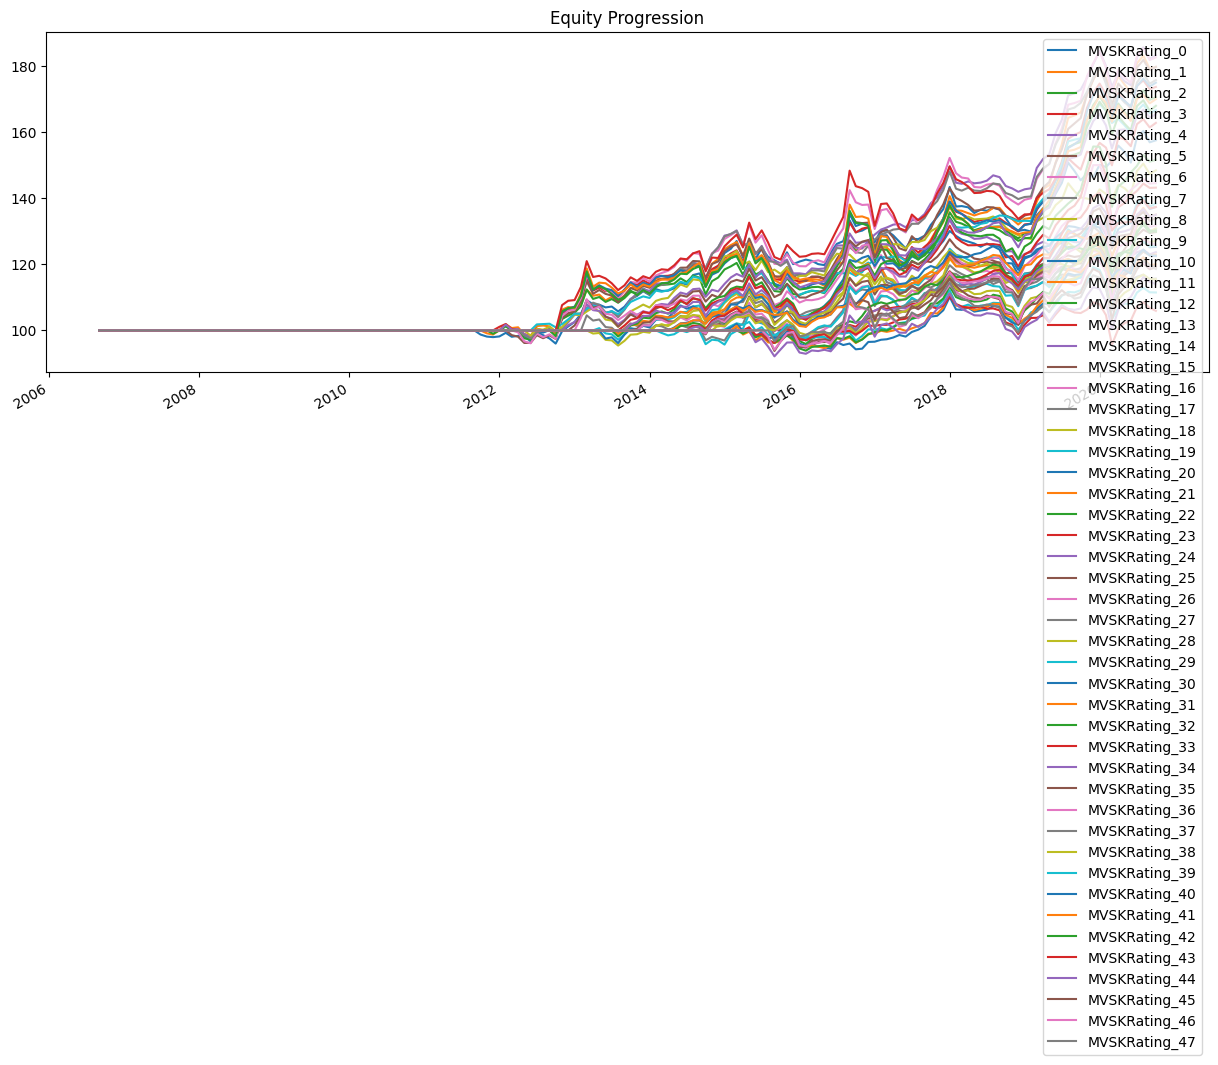

In [13]:
res.plot()

In [14]:
#res.plot_weights()
res.get_weights()

,MVSKRating_0,MVSKRating_0>6,MVSKRating_0>17,MVSKRating_0>21,MVSKRating_0>23,MVSKRating_0>24,MVSKRating_0>43,MVSKRating_0>47,MVSKRating_0>51,MVSKRating_0>60,...,MVSKRating_0>124,MVSKRating_0>126,MVSKRating_0>134,MVSKRating_0>146,MVSKRating_0>147,MVSKRating_0>148,MVSKRating_0>149,MVSKRating_0>150,MVSKRating_0>176,MVSKRating_0>182
2006-08-31,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2006-09-01,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2006-10-01,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2006-11-01,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2006-12-01,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-01,1.0,0.035275,0.025072,0.029126,0.023721,0.023580,0.036319,0.024688,0.029162,0.031519,...,0.020849,0.025873,0.017491,0.031767,0.030616,0.019913,0.020146,0.040256,0.032983,0.023877
2020-07-01,1.0,0.035368,0.024092,0.028227,0.022689,0.022591,0.034150,0.024182,0.028508,0.030506,...,0.020001,0.025345,0.016490,0.030604,0.029478,0.017092,0.017298,0.039691,0.031321,0.022730
2020-08-01,1.0,0.033741,0.022531,0.027918,0.022719,0.022743,0.034299,0.025570,0.029836,0.029838,...,0.020831,0.024659,0.018582,0.030209,0.029080,0.017008,0.017214,0.039289,0.030876,0.021752
2020-09-01,1.0,0.032176,0.022785,0.028549,0.022782,0.022578,0.033224,0.024486,0.030352,0.030323,...,0.021642,0.025701,0.019149,0.030873,0.029701,0.017433,0.017648,0.040072,0.031378,0.022177


In [15]:
res.display()

Stat                 MVSKRating_0    MVSKRating_1    MVSKRating_2    MVSKRating_3    MVSKRating_4    MVSKRating_5    MVSKRating_6    MVSKRating_7    MVSKRating_8    MVSKRating_9    MVSKRating_10    MVSKRating_11    MVSKRating_12    MVSKRating_13    MVSKRating_14    MVSKRating_15    MVSKRating_16    MVSKRating_17    MVSKRating_18    MVSKRating_19    MVSKRating_20    MVSKRating_21    MVSKRating_22    MVSKRating_23    MVSKRating_24    MVSKRating_25    MVSKRating_26    MVSKRating_27    MVSKRating_28    MVSKRating_29    MVSKRating_30    MVSKRating_31    MVSKRating_32    MVSKRating_33    MVSKRating_34    MVSKRating_35    MVSKRating_36    MVSKRating_37    MVSKRating_38    MVSKRating_39    MVSKRating_40    MVSKRating_41    MVSKRating_42    MVSKRating_43    MVSKRating_44    MVSKRating_45    MVSKRating_46    MVSKRating_47
-------------------  --------------  --------------  --------------  --------------  --------------  --------------  --------------  --------------  --------------  -----------

In [16]:
# Expect this to be 40.778% for MVSK
# Expect this to be 42.246% for LMoments
res.stats.loc['total_return',].mean()*100

np.float64(40.63373681590145)

# Run on student's data

In [23]:
f"{LMoments.__name__}"

'LMoments'

In [17]:
from Master1_MH_RA.fundrating import splitMomentsToXY, RApreferences
from typing import Tuple
import numpy as np

def TF_RA_costs(moments_df: pd.DataFrame) -> Tuple[np.ndarray]:
    XOBS, YOBS = splitMomentsToXY(moments_df)
    XOBS = np.concatenate([XOBS, data_costs.to_numpy()], axis=1)
    gX, gY = RApreferences(XOBS, YOBS)
    return XOBS, YOBS, gX, gY

In [ ]:
testlist = getBackTestList(data_prices.sort_index(), max_window_years=4, getXYgXgY=TF_RA_costs, nr_moments=3)
res_student = bt.run(*testlist)
#res_student.stats.to_excel("TF_RA_MVSK_nonconvex.xlsx")
#res_student.stats.to_excel("TF_RA_LMoments_nonconvex.xlsx")
res_student.stats.to_excel("TF_RA_MVSK_convex.xlsx")

Number of rebalances is: 23


  0%|          | 0/23 [9:29:21<?, ?it/s]


In [ ]:
res_student.stats.loc['total_return',].mean()*100

np.float64(30.131994941114815)

<Axes: title={'center': 'Equity Progression'}>

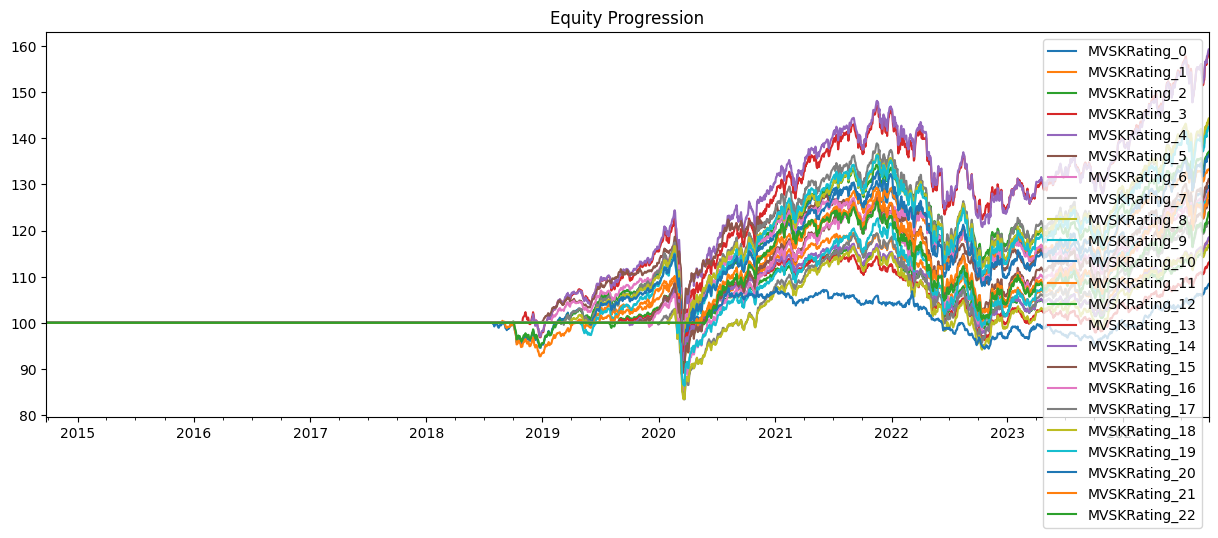

In [ ]:
res_student.plot()

In [ ]:
res_student.get_weights()

,MVSKRating_0,MVSKRating_0>CMIIMXI LX Equity,MVSKRating_0>BRVSIIC LN Equity,MVSKRating_0>BRVS3CA LN Equity,MVSKRating_0>MRCGRFI LN Equity,MVSKRating_0>AZCMESA LX Equity,MVSKRating_0>CSADGBA LX Equity,MVSKRating_0>JD1SVCP LX Equity,MVSKRating_0>MKCORFV LX Equity,MVSKRating_0>IAMNUPA LX Equity,...,MVSKRating_0>AVGSDHI LX Equity,MVSKRating_0>PLUSA SW Equity,MVSKRating_0>CLAMOB3 FP Equity,MVSKRating_0>BNPNAPA FP Equity,MVSKRating_0>BNPPHPA FP Equity,MVSKRating_0>BNPFOPO FP Equity,MVSKRating_0>BNPPHAP FP Equity,MVSKRating_0>NCJEJOA ID Equity,MVSKRating_0>BRC100A LN Equity,MVSKRating_0>500 FP Equity
2014-09-24,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2014-09-25,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2014-09-26,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2014-09-29,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2014-09-30,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-19,1.0,0.037468,0.031500,0.033275,0.028683,0.027513,0.028443,0.039631,0.028609,0.027955,...,0.031586,0.027803,0.021862,0.041189,0.023320,0.025410,0.029733,0.033659,0.041325,0.057111
2024-09-20,1.0,0.037753,0.031433,0.033207,0.028625,0.027492,0.028410,0.039768,0.028385,0.027785,...,0.031543,0.027778,0.021834,0.041152,0.023298,0.025387,0.029705,0.034146,0.041225,0.056812
2024-09-23,1.0,0.037591,0.031365,0.033122,0.028482,0.027503,0.028416,0.039612,0.028559,0.027784,...,0.031551,0.027466,0.021847,0.041188,0.023333,0.025431,0.029319,0.034144,0.041060,0.057176
2024-09-24,1.0,0.037362,0.031326,0.033100,0.028322,0.027452,0.028407,0.039664,0.028660,0.027732,...,0.031495,0.027415,0.021817,0.041111,0.023290,0.025384,0.029265,0.034352,0.040983,0.056982


In [ ]:
res_student.stats

,MVSKRating_0
start,2014-09-24 00:00:00
end,2024-09-25 00:00:00
rf,0.0
total_return,0.360462
cagr,0.031248
max_drawdown,-0.206863
calmar,0.151057
mtd,0.005
three_month,0.009924
six_month,0.032737
